In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Walmart DataSet.csv to Walmart DataSet.csv


In [4]:
df = pd.read_csv('Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [35]:
df.shape

(6435, 8)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [37]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [38]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [39]:
# Converting Date Column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


In [40]:
# Set Date as Index
df.set_index('Date', inplace=True)
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-05,10,2193048.75,0,54.34,2.962,126.442065,9.765
2010-02-05,37,536006.73,0,45.97,2.572,209.852966,8.554
2010-02-05,17,789036.02,0,23.11,2.666,126.442065,6.548
2010-02-05,30,465108.52,0,39.05,2.572,210.752605,8.324


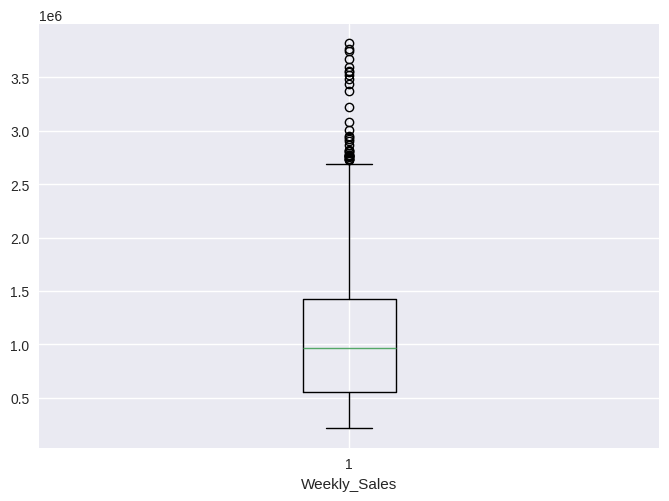

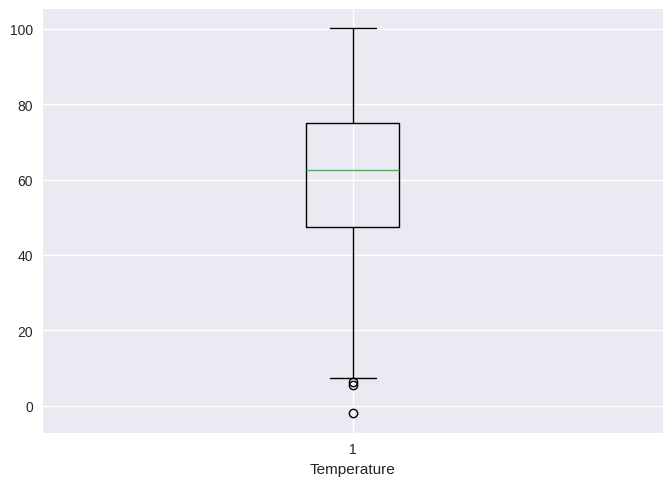

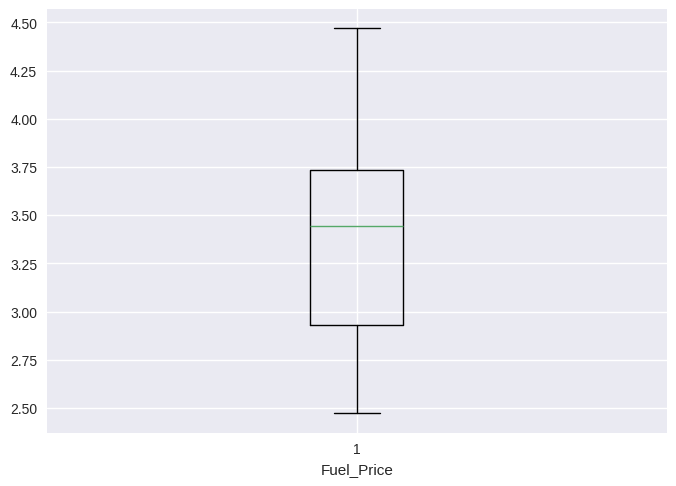

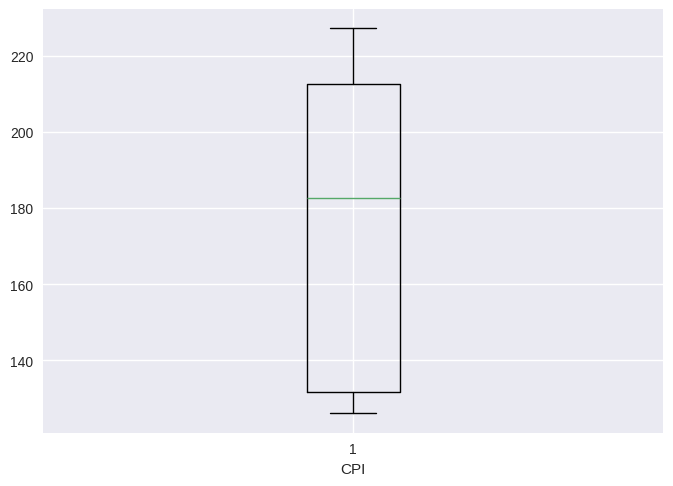

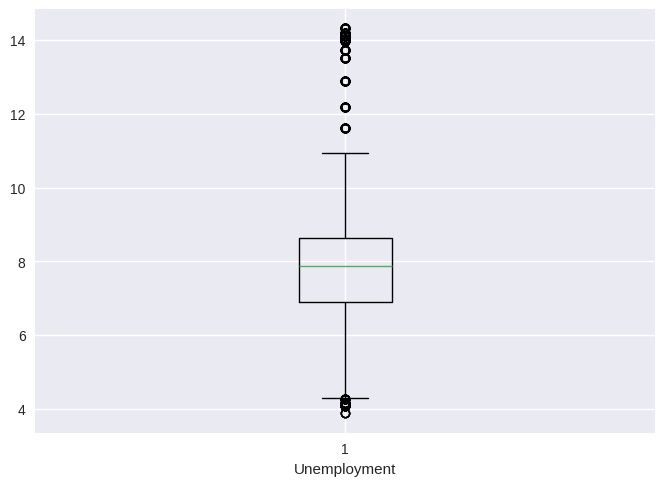

In [43]:
num_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
for col in num_cols:
  plt.boxplot(df[col])
  plt.xlabel(col)
  plt.show()

In [44]:
out_cols = ['Weekly_Sales','Temperature','Unemployment']
for col in out_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

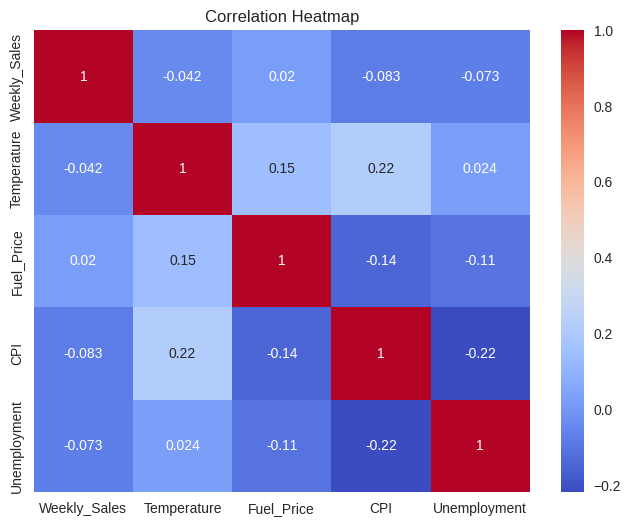

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

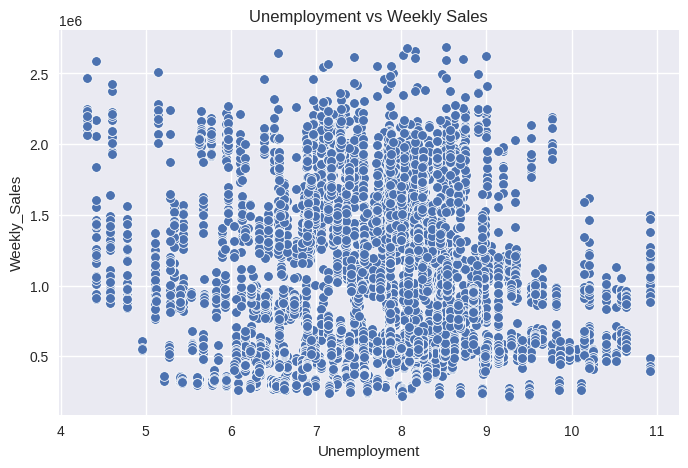

In [47]:
# QUESTION (a)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Unemployment'], y=df['Weekly_Sales'])
plt.title("Unemployment vs Weekly Sales")
plt.show()

In [48]:
unemp_sales = df.groupby('Store')[['Weekly_Sales','Unemployment']].mean()
unemp_sales.sort_values('Unemployment', ascending=False).head()

,Weekly_Sales,Unemployment
Store,,
12,9.639242e+05,10.754941
38,4.321988e+05,10.754941
28,1.241575e+06,10.754941
43,6.333247e+05,9.934804
34,9.667816e+05,9.934804


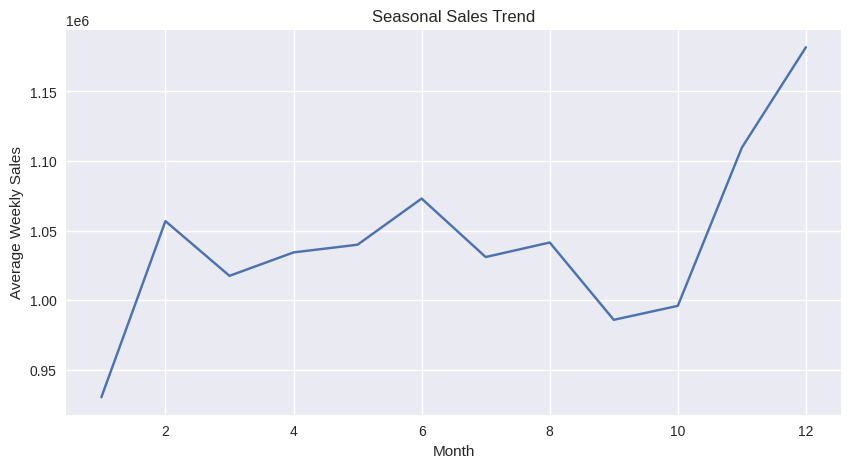

In [49]:
# QUESTION (b)
df['Month'] = df.index.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(figsize=(10,5))
plt.title("Seasonal Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

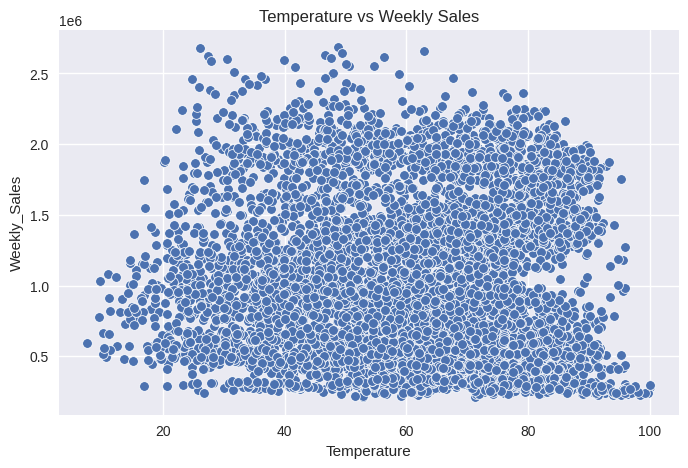

In [50]:
# QUESTION (c)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])
plt.title("Temperature vs Weekly Sales")
plt.show()

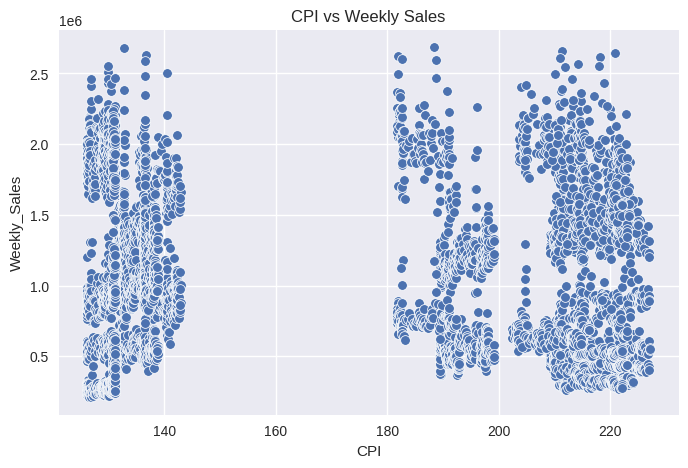

In [52]:
# QUESTION (d)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['CPI'], y=df['Weekly_Sales'])
plt.title("CPI vs Weekly Sales")
plt.show()

In [53]:
# QUESTION (e)
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales.head(10)

,Weekly_Sales
Store,
20,2.800237e+08
14,2.761276e+08
2,2.687221e+08
13,2.682025e+08
10,2.556789e+08
27,2.480387e+08
4,2.446487e+08
1,2.224028e+08
6,2.210286e+08


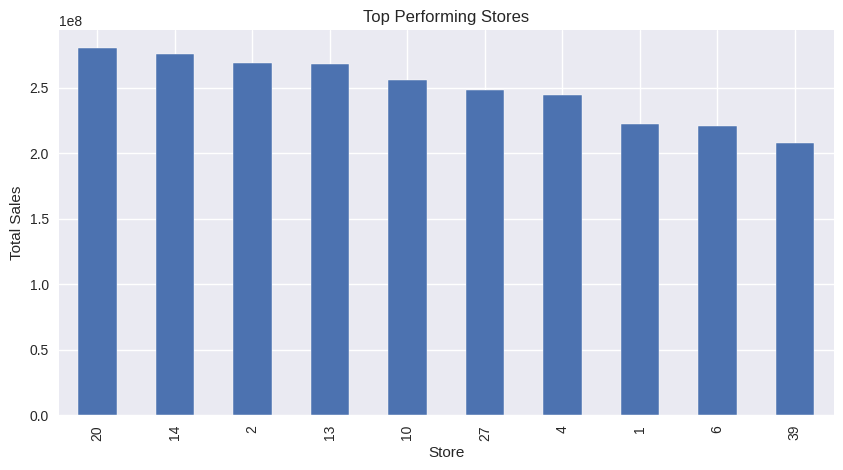

In [54]:
# Plot Top Stores
store_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Performing Stores")
plt.ylabel("Total Sales")
plt.show()

In [55]:
# QUESTION (f)
store_sales.tail(5)

,Weekly_Sales
Store,
44,43293087.84
33,37160221.96
28,21106767.80
12,16386710.79
38,7347378.89


In [56]:
# Difference Between Best & Worst
best = store_sales.max()
worst = store_sales.min()
print("Best Store Sales:", best)
print("Worst Store Sales:", worst)
print("Difference:", best - worst)

Best Store Sales: 280023734.81
Worst Store Sales: 7347378.89
Difference: 272676355.92


In [57]:
top5 = store_sales.head(5).index
top5

Index([20, 14, 2, 13, 10], dtype='int64', name='Store')

In [58]:
store_id = top5[0]
store_data = df[df['Store'] == store_id]
sales = store_data.groupby(store_data.index)['Weekly_Sales'].sum()
sales.head()

,Weekly_Sales
Date,
2010-02-05,2401395.47
2010-02-12,2109107.90
2010-02-19,2161549.76
2010-02-26,1898193.95
2010-03-05,2119213.72


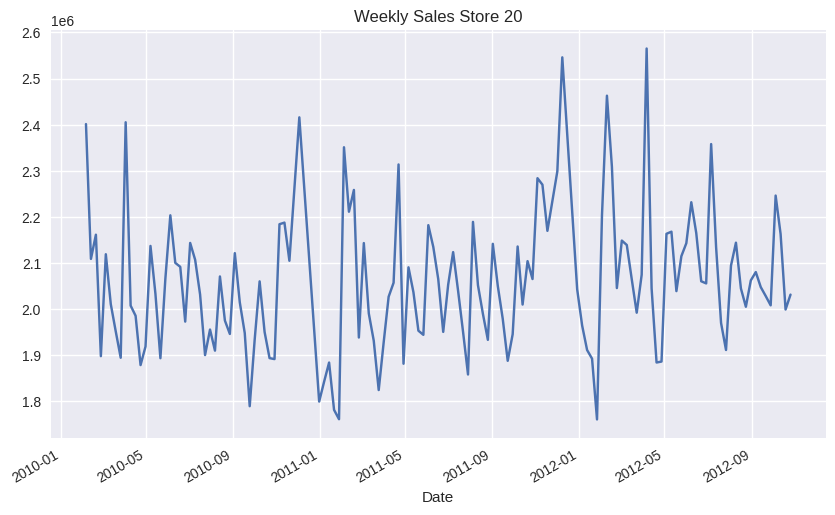

In [59]:
sales.plot(figsize=(10,6),
           title=f"Weekly Sales Store {store_id}")
plt.show()

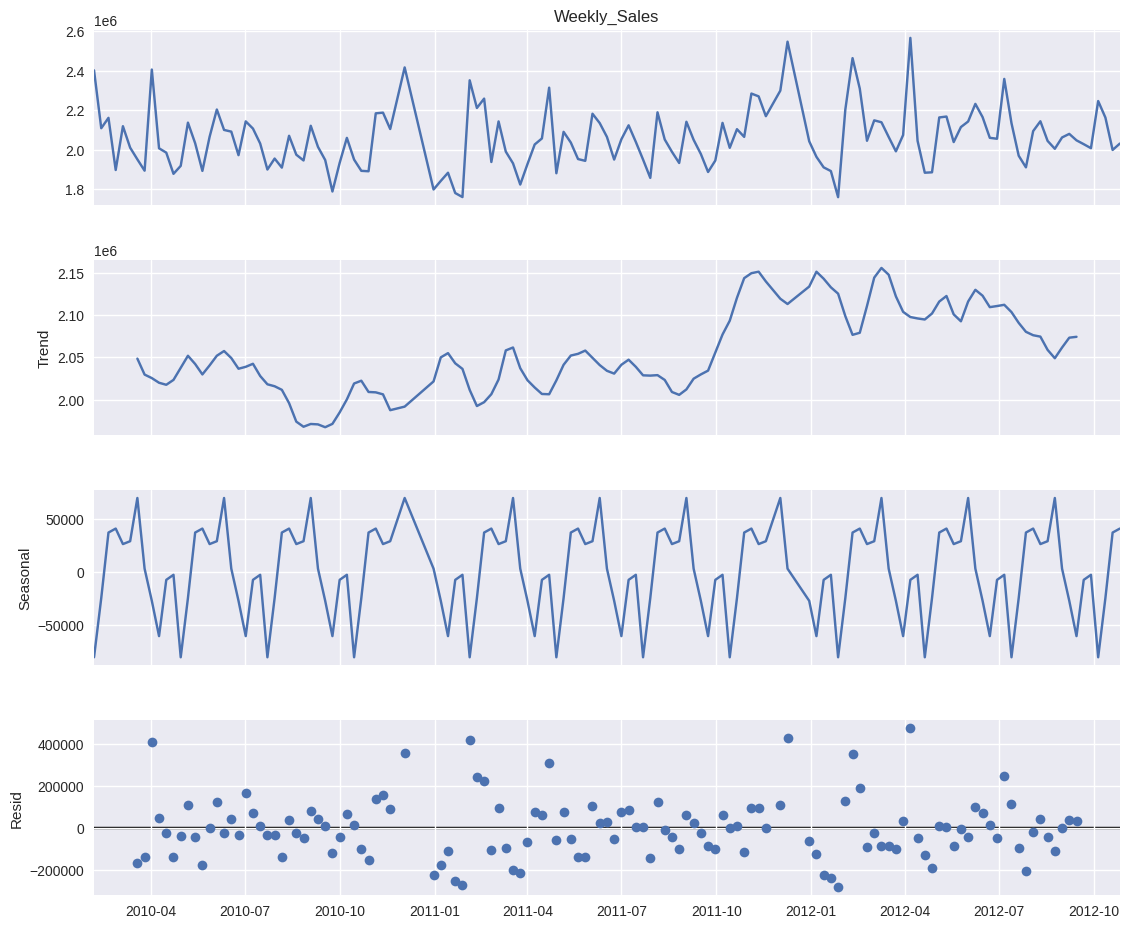

In [60]:
decomposition = seasonal_decompose(sales, period=12)
fig = decomposition.plot()
fig.set_size_inches(12,10)
plt.show()

In [61]:
model = sm.tsa.statespace.SARIMAX(
        sales,
        order=(4,4,3),
        seasonal_order=(1,1,0,52),
        enforce_invertibility=False
)
results = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [62]:
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  136
Model:             SARIMAX(4, 4, 3)x(1, 1, [], 52)   Log Likelihood               -1127.161
Date:                             Mon, 09 Mar 2026   AIC                           2272.321
Time:                                     15:22:12   BIC                           2293.760
Sample:                                          0   HQIC                          2280.917
                                             - 136                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2392      0.935     -1.325      0.185      -3.072       0.593
ar.L2         -1.4045      

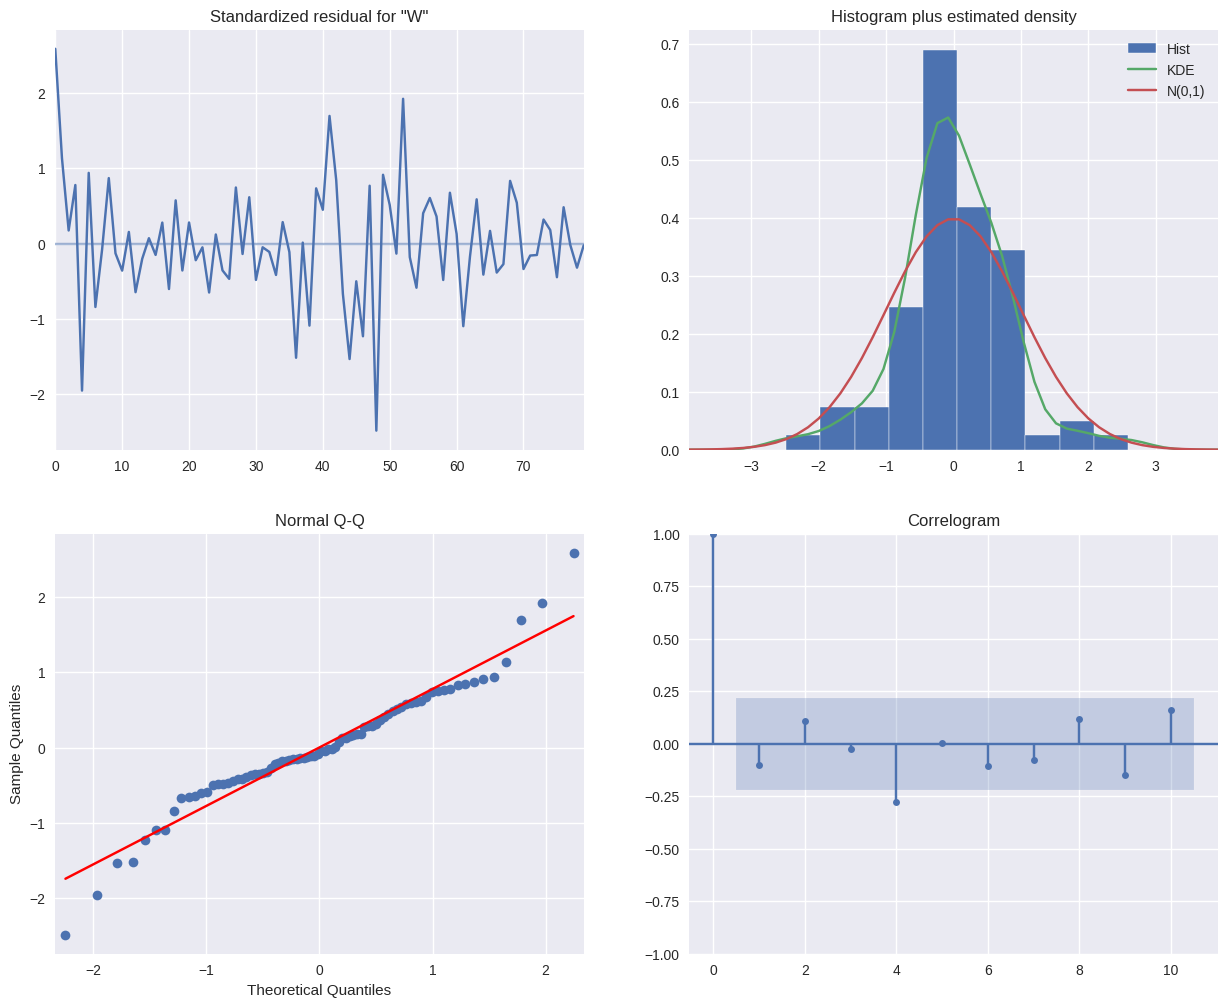

In [64]:
results.plot_diagnostics(figsize=(15,12))
plt.show()

In [81]:
pred = results.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()
pred_ci

,lower Weekly_Sales,upper Weekly_Sales
Date,,
2012-07-27,1.433779e+06,2.632695e+06
2012-08-03,1.174483e+06,2.373310e+06
2012-08-10,1.429079e+06,2.627817e+06
2012-08-17,1.336185e+06,2.534832e+06
2012-08-24,1.257868e+06,2.456423e+06
2012-08-31,1.096578e+06,2.295044e+06
2012-09-07,8.196697e+05,2.018046e+06
2012-09-14,1.086045e+06,2.284334e+06
2012-09-21,8.988023e+05,2.097008e+06


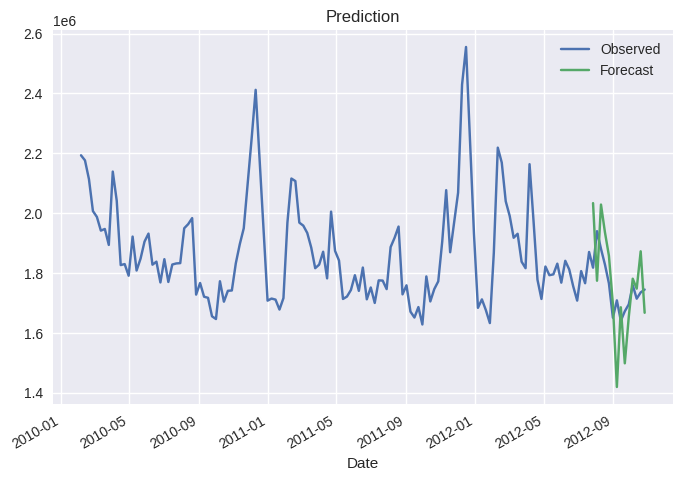

In [82]:
ax = sales['2010':].plot(label='Observed')
pred.predicted_mean.plot(ax=ax, label='Forecast')
plt.title('Prediction')
plt.legend()
plt.show()

In [69]:
y_forecasted = pred.predicted_mean
y_truth = sales['2012-7-27':]
mse = ((y_forecasted - y_truth) ** 2).mean()
print("MSE:", round(mse,2))

MSE: 21301054728.97


In [70]:
pred_uc = results.get_forecast(steps=12)
pred_ci = pred_uc.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


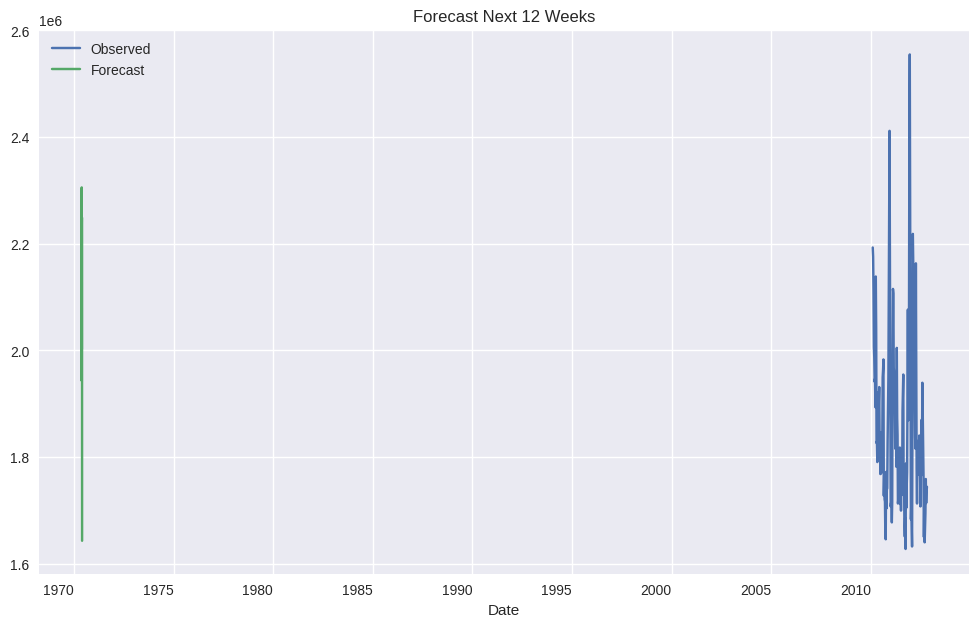

In [75]:
ax = sales.plot(label='Observed', figsize=(12,8))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
plt.title('Forecast Next 12 Weeks')
plt.legend()
plt.show()

Forecasting Store: 20


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/stat

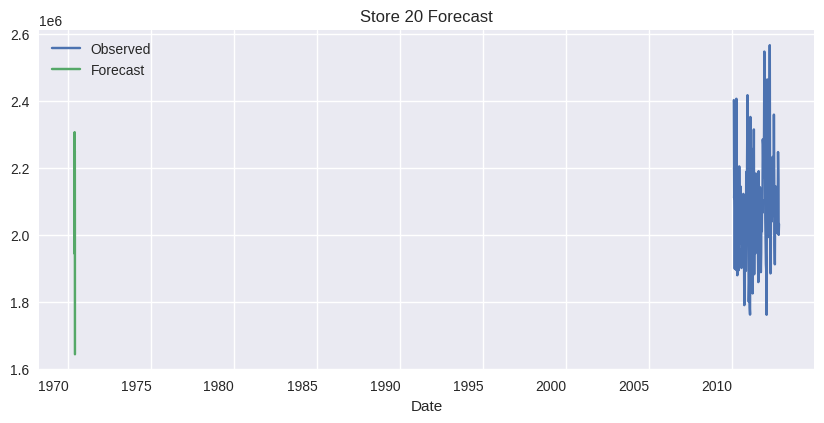

Forecasting Store: 14


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dis

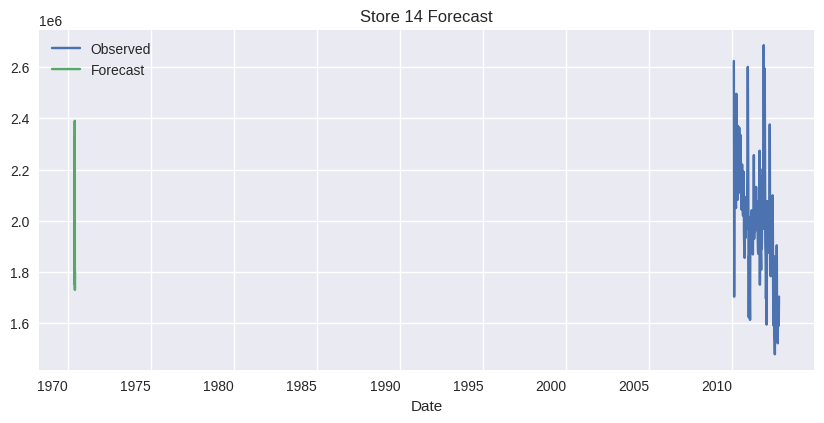

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecasting Store: 2


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


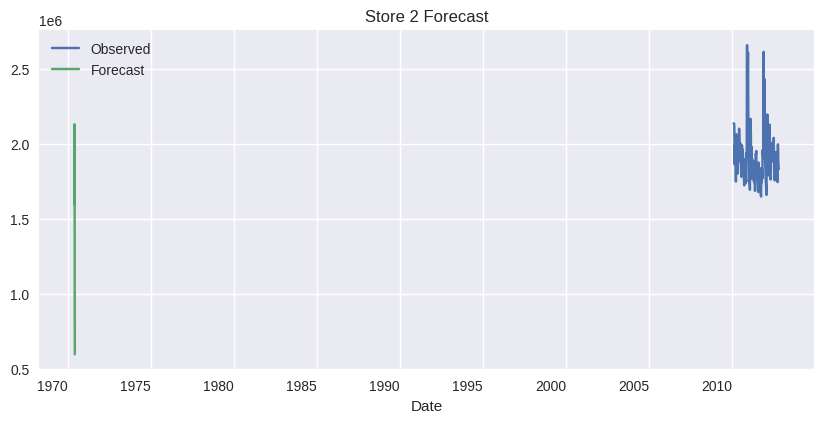

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecasting Store: 13


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


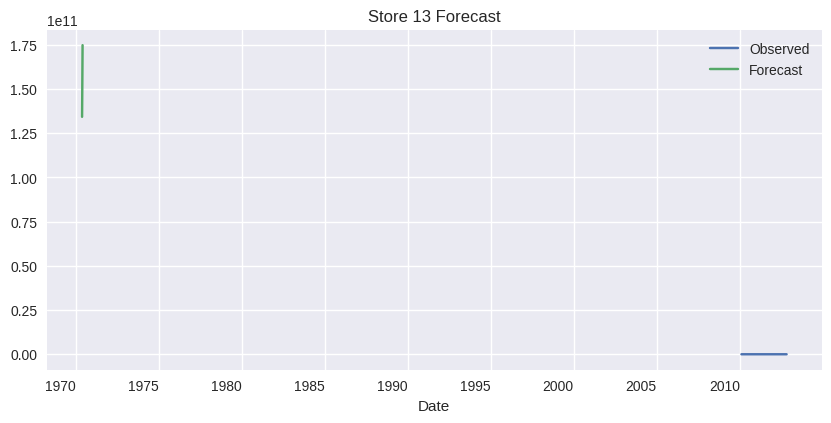

Forecasting Store: 10


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/stat

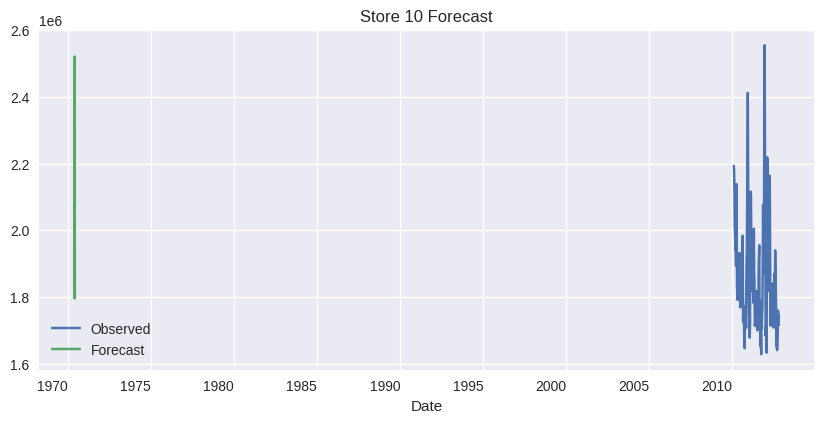

In [76]:
for store_id in top5:
    print("Forecasting Store:", store_id)
    store_data = df[df['Store'] == store_id]
    sales = store_data.groupby(store_data.index)['Weekly_Sales'].sum()
    model = sm.tsa.statespace.SARIMAX(
            sales,
            order=(4,4,3),
            seasonal_order=(1,1,0,52),
            enforce_invertibility=False
    )
    results = model.fit()
    forecast = results.get_forecast(steps=12)
    plt.figure(figsize=(10,5))
    sales.plot(label="Observed")
    forecast.predicted_mean.plot(label="Forecast")
    plt.title(f"Store {store_id} Forecast")
    plt.legend()
    plt.show()

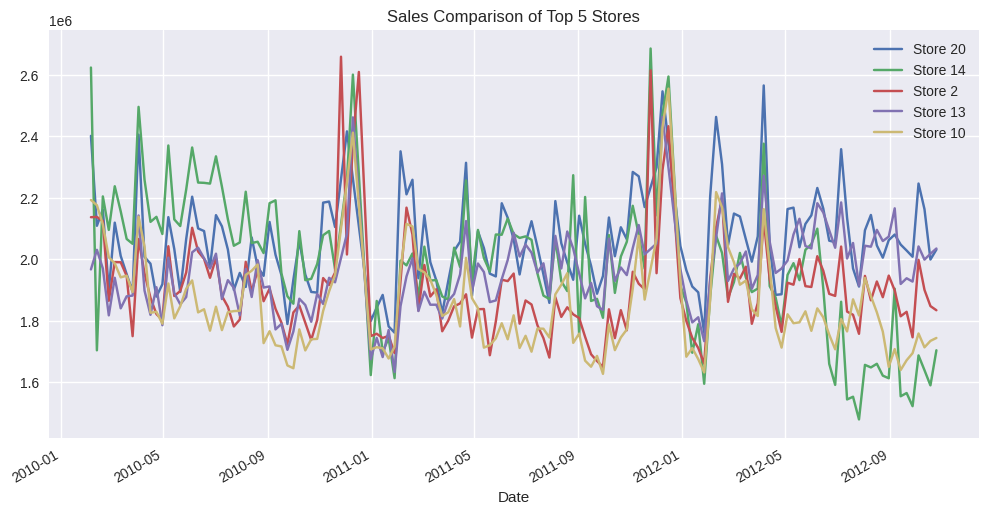

In [77]:
plt.figure(figsize=(12,6))
for store_id in top5:
    store_data = df[df['Store'] == store_id]
    sales = store_data.groupby(store_data.index)['Weekly_Sales'].sum()
    sales.plot(label=f"Store {store_id}")
plt.title("Sales Comparison of Top 5 Stores")
plt.legend()
plt.show()